# From GPT to SmolVLA — Part 2: building the action expert from scratch

In **Part 1** you built a decoder-only GPT: embed tokens → stack of *causal self-attention* + FFN
blocks → project to vocab logits → cross-entropy → autoregressive `generate()`. In the original
Transformer figure, that is the **decoder stack with the cross-attention removed**.

**SmolVLA's action expert is that same decoder stack with the cross-attention put *back*** — plus a
different output head and a different training objective. This notebook builds exactly that delta, in
the same from-scratch, one-idea-at-a-time style, and trains it on a toy robot task so every piece runs
on a CPU in seconds. (Faithful to `SmolVLA.pdf` §3.1.)

### The three deltas from your GPT
| | GPT (Part 1) | SmolVLA action expert (here) |
|---|---|---|
| **Output** | discrete token, softmax over vocab | **continuous action chunk** $\mathbf{A}=(\mathbf{a}_t,\dots,\mathbf{a}_{t+n})$ |
| **Objective** | cross-entropy (classification) | **flow matching** — regress a velocity field (§3.1) |
| **Attention** | causal self-attention only | **interleaved cross-attn (CA) + causal self-attn (SA)** |
| **Conditioning** | previous characters | **VLM features** $\mathbf{o}_t$ (image + language + state token) |

We tackle them in that order: first *what the model outputs* (continuous actions + flow matching),
then *how it reads the world* (cross-attention), then we assemble and train the whole expert.


## The big picture — SmolVLA drawn as the original Transformer figure

The original two-stack figure (SmolVLA in the layout of *Attention Is All You Need*, Fig. 1), now
**annotated with the code**: each box carries the `nn.Module` it runs, and each connecting line carries
the matching `forward()` equation. **Right** = the real action-expert modules; **left** = the toy
`make_batch` stand-in for SmolVLM-2 (fixed tensors `Wg`, `Wf`). The orange arrow is cross-attention:
`oₜ` becomes the keys/values `f` that the CA box reads.

**Run the cell below to draw it** (rendered from code so the SVG isn't stripped by the notebook viewer).

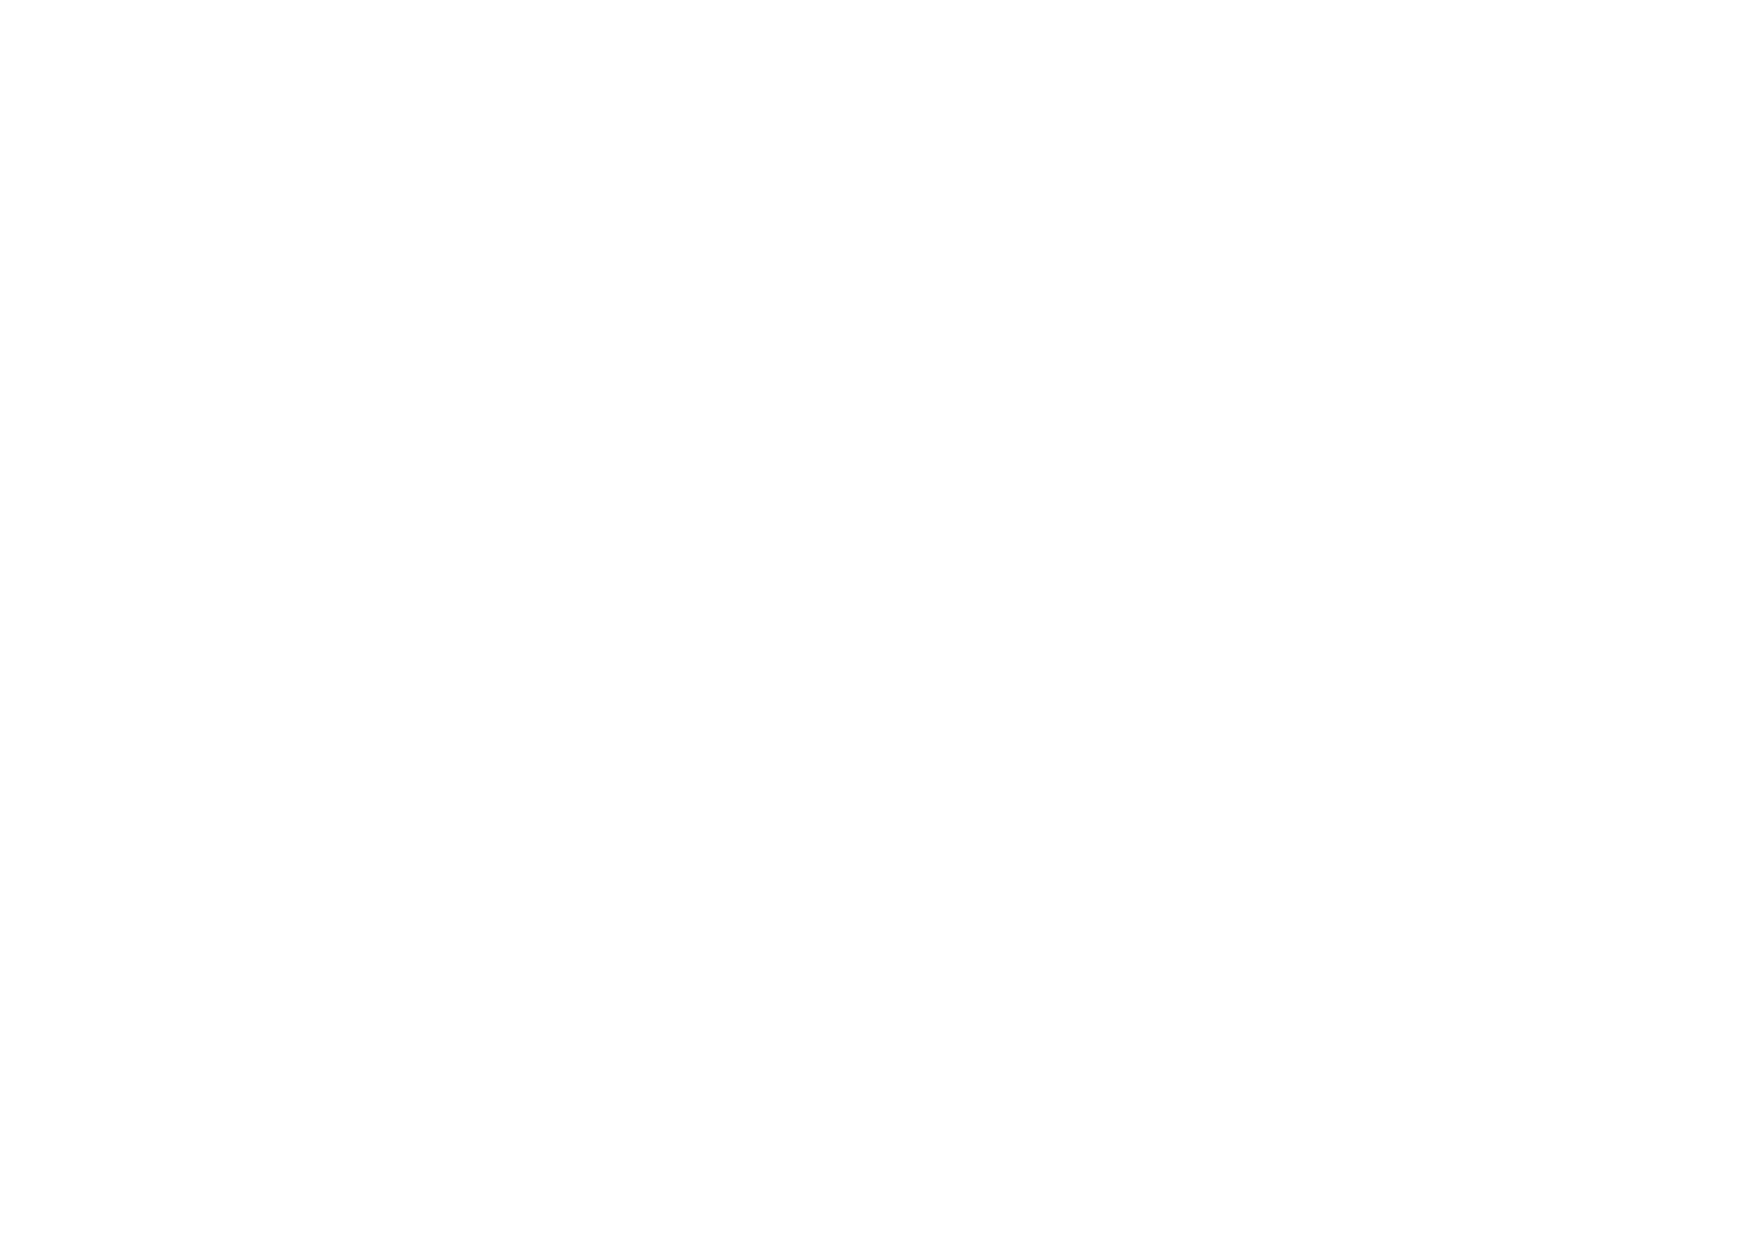

In [46]:
from IPython.display import SVG, display

_svg = r"""<svg viewBox="-320 -8 1740 1246" width="100%" style="max-width:1220px;height:auto;display:block;margin:auto" xmlns="http://www.w3.org/2000/svg" role="img" aria-label="SmolVLA in the style of the original Transformer Figure 1">
<rect x="-320" y="-8" width="1740" height="1246" rx="16" fill="#FBFAF6"/>
<defs><marker id="ah" viewBox="0 0 8 8" refX="6.5" refY="4" markerWidth="7" markerHeight="7" orient="auto-start-reverse"><path d="M0,0 L7,4 L0,8 z" fill="#4A463E"/></marker></defs>
<path d="M174,1103 V1088 H300 V1053" fill="none" stroke="#4A463E" stroke-width="1.8"/>
<path d="M300,1103 V1053" fill="none" stroke="#4A463E" stroke-width="1.8"/>
<path d="M426,1103 V1088 H300" fill="none" stroke="#4A463E" stroke-width="1.8"/>
<path d="M300,1053 V727" fill="none" stroke="#4A463E" stroke-width="1.8" marker-end="url(#ah)"/>
<path d="M780,1103 V443" fill="none" stroke="#4A463E" stroke-width="1.8" marker-end="url(#ah)"/>
<circle cx="300" cy="1050" r="8" fill="#FBFAF6" stroke="#4A463E" stroke-width="1.4"/><text x="300" y="1054" text-anchor="middle" font-size="13" fill="#33302A" font-family="Georgia,Times New Roman,serif">+</text>
<text x="348" y="1054" text-anchor="start" font-size="10.5" fill="#6b6456" font-family="Georgia,Times New Roman,serif">pos. enc.</text>
<circle cx="780" cy="1078" r="8" fill="#FBFAF6" stroke="#4A463E" stroke-width="1.4"/><text x="780" y="1082" text-anchor="middle" font-size="13" fill="#33302A" font-family="Georgia,Times New Roman,serif">+</text>
<text x="828" y="1082" text-anchor="start" font-size="10.5" fill="#6b6456" font-family="Georgia,Times New Roman,serif">pos. + &#964;</text>
<rect x="120" y="758" width="360" height="288" rx="12" fill="none" stroke="#B4AEA1" stroke-width="1.3" stroke-dasharray="5 5"/>
<rect x="600" y="618" width="360" height="428" rx="12" fill="none" stroke="#B4AEA1" stroke-width="1.3" stroke-dasharray="5 5"/>
<text x="300" y="750" text-anchor="middle" font-size="12.5" fill="#7C7566" font-style="italic" font-family="Georgia,Times New Roman,serif">SmolLM2 decoder &#183; VLM backbone (SmolVLM-2)</text>
<text x="780" y="610" text-anchor="middle" font-size="12.5" fill="#7C7566" font-style="italic" font-family="Georgia,Times New Roman,serif">flow-matching action expert  v&#952;  (hidden 0.75&#183;d)</text>
<path d="M112,766 h-8 V1038 h8" fill="none" stroke="#B4AEA1" stroke-width="1.3"/>
<text x="70" y="906" transform="rotate(-90 70 906)" text-anchor="middle" font-size="13" fill="#6b6456" font-style="italic" font-family="Georgia,Times New Roman,serif">N = L/2 &#215;</text>
<path d="M968,626 h8 V1038 h-8" fill="none" stroke="#B4AEA1" stroke-width="1.3"/>
<text x="1006" y="832" transform="rotate(90 1006 832)" text-anchor="middle" font-size="13" fill="#6b6456" font-style="italic" font-family="Georgia,Times New Roman,serif">interleaved CA / SA &#215; N</text>
<rect x="120" y="1103" width="108" height="46" rx="8" fill="#F6CFC9" stroke="#CE8E86" stroke-width="1.4"/><text x="174" y="1122" text-anchor="middle" font-size="12.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">SigLIP +</text><text x="174" y="1138" text-anchor="middle" font-size="12.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">pixel-shuffle</text>
<rect x="246" y="1103" width="108" height="46" rx="8" fill="#F6CFC9" stroke="#CE8E86" stroke-width="1.4"/><text x="300" y="1130" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Tokenizer</text>
<rect x="372" y="1103" width="108" height="46" rx="8" fill="#F6CFC9" stroke="#CE8E86" stroke-width="1.4"/><text x="426" y="1122" text-anchor="middle" font-size="12.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Linear &#8594;</text><text x="426" y="1138" text-anchor="middle" font-size="12.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">state token</text>
<text x="174" y="1170" text-anchor="middle" font-size="12.5" fill="#33302A" font-style="italic" font-family="Georgia,Times New Roman,serif">Camera images</text><text x="174" y="1185" text-anchor="middle" font-size="11" fill="#6b6456" font-family="Georgia,Times New Roman,serif">&#8594; 64 visual tokens</text>
<text x="300" y="1170" text-anchor="middle" font-size="12.5" fill="#33302A" font-style="italic" font-family="Georgia,Times New Roman,serif">Language instruction</text>
<text x="426" y="1170" text-anchor="middle" font-size="12.5" fill="#33302A" font-style="italic" font-family="Georgia,Times New Roman,serif">Robot state</text><text x="426" y="1185" text-anchor="middle" font-size="11" fill="#6b6456" font-family="Georgia,Times New Roman,serif">&#8594; 1 token</text>
<rect x="150" y="979" width="300" height="42" rx="8" fill="#F8C98C" stroke="#CF9445" stroke-width="1.4"/><text x="300" y="1005" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Multi-Head Self-Attention</text>
<rect x="150" y="909" width="300" height="42" rx="8" fill="#FBF0A6" stroke="#CBB85A" stroke-width="1.4"/><text x="300" y="935" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Add &amp; Norm</text>
<rect x="150" y="839" width="300" height="42" rx="8" fill="#C6DCEF" stroke="#7AA6C9" stroke-width="1.4"/><text x="300" y="865" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Feed Forward</text>
<rect x="150" y="769" width="300" height="42" rx="8" fill="#FBF0A6" stroke="#CBB85A" stroke-width="1.4"/><text x="300" y="795" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Add &amp; Norm</text>
<rect x="150" y="683" width="300" height="44" rx="8" fill="#E7E3DA" stroke="#B4AEA1" stroke-width="1.4"/><text x="300" y="702" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">VLM features  o&#8348;</text><text x="300" y="718" text-anchor="middle" font-size="11" fill="#6b6456" font-family="Georgia,Times New Roman,serif">taken at layer N = L/2 (layer skip)</text>
<rect x="630" y="1103" width="300" height="46" rx="8" fill="#F6CFC9" stroke="#CE8E86" stroke-width="1.4"/><text x="780" y="1122" text-anchor="middle" font-size="13" fill="#33302A" font-family="Georgia,Times New Roman,serif">Linear proj + position + &#964;-embed</text><text x="780" y="1138" text-anchor="middle" font-size="11" fill="#6b6456" font-family="Georgia,Times New Roman,serif">(the noised action chunk becomes tokens)</text>
<text x="780" y="1170" text-anchor="middle" font-size="12.5" fill="#33302A" font-style="italic" font-family="Georgia,Times New Roman,serif">Noisy action chunk  A&#7511;  + flow time &#964;</text>
<rect x="630" y="979" width="300" height="42" rx="8" fill="#F8C98C" stroke="#CF9445" stroke-width="1.4"/><text x="780" y="1005" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Masked (causal) Self-Attention</text>
<rect x="630" y="909" width="300" height="42" rx="8" fill="#FBF0A6" stroke="#CBB85A" stroke-width="1.4"/><text x="780" y="935" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Add &amp; Norm</text>
<rect x="630" y="839" width="300" height="42" rx="8" fill="#F8C98C" stroke="#CF9445" stroke-width="1.4"/><text x="780" y="865" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Multi-Head Cross-Attention</text>
<rect x="630" y="769" width="300" height="42" rx="8" fill="#FBF0A6" stroke="#CBB85A" stroke-width="1.4"/><text x="780" y="795" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Add &amp; Norm</text>
<rect x="630" y="699" width="300" height="42" rx="8" fill="#C6DCEF" stroke="#7AA6C9" stroke-width="1.4"/><text x="780" y="725" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Feed Forward</text>
<rect x="630" y="629" width="300" height="42" rx="8" fill="#FBF0A6" stroke="#CBB85A" stroke-width="1.4"/><text x="780" y="655" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Add &amp; Norm</text>
<rect x="655" y="539" width="250" height="42" rx="8" fill="#D9CBE9" stroke="#A08CC0" stroke-width="1.4"/><text x="780" y="565" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Linear</text>
<rect x="645" y="464" width="270" height="52" rx="8" fill="#C8E6C0" stroke="#77AE6C" stroke-width="1.4"/><text x="780" y="486" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Flow matching</text><text x="780" y="503" text-anchor="middle" font-size="11" fill="#6b6456" font-family="Georgia,Times New Roman,serif">integrate v&#952; over &#964;: 0 &#8594; 1</text>
<rect x="655" y="397" width="250" height="46" rx="8" fill="#E7E3DA" stroke="#B4AEA1" stroke-width="1.4"/><text x="780" y="416" text-anchor="middle" font-size="14.5" fill="#33302A" font-family="Georgia,Times New Roman,serif">Action chunk  A&#8348;</text><text x="780" y="432" text-anchor="middle" font-size="11" fill="#6b6456" font-family="Georgia,Times New Roman,serif">(a&#8348;, &#8230;, a&#8348;&#8330;&#8345;)</text>
<text x="780" y="378" text-anchor="middle" font-size="12.5" fill="#7C7566" font-style="italic" font-family="Georgia,Times New Roman,serif">Output: continuous actions</text>
<path d="M450,699 H556 V858 H628" fill="none" stroke="#B5502E" stroke-width="1.8" marker-end="url(#ah)"/>
<path d="M450,714 H572 V872 H628" fill="none" stroke="#B5502E" stroke-width="1.8" marker-end="url(#ah)"/>
<text x="512" y="690" text-anchor="middle" font-size="11.5" fill="#B5502E" font-style="italic" font-family="Georgia,Times New Roman,serif">features o&#8348;</text>
<text x="512" y="758" text-anchor="middle" font-size="11.5" fill="#B5502E" font-style="italic" font-family="Georgia,Times New Roman,serif">&#8594; keys, values</text>

<text x="780" y="1017" text-anchor="middle" font-size="8.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">attn[1] = MHA(d, n_heads, causal=True)</text>
<text x="780" y="947" text-anchor="middle" font-size="8.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln = nn.LayerNorm(d)</text>
<text x="780" y="877" text-anchor="middle" font-size="8.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">attn[0] = MHA(d, n_heads, causal=False)</text>
<text x="780" y="807" text-anchor="middle" font-size="8.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln = nn.LayerNorm(d)</text>
<text x="780" y="737" text-anchor="middle" font-size="8.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">ff = FeedForward(d)</text>
<text x="780" y="667" text-anchor="middle" font-size="8.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln = nn.LayerNorm(d)</text>
<text x="780" y="577" text-anchor="middle" font-size="8.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">out = nn.Linear(d, ACTION_DIM)</text>
<path d="M930,1122 H952" stroke="#B5502E" stroke-width="1.1" fill="none"/><text x="958" y="1121" text-anchor="start" font-size="11" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = in_proj(A^τ) + pos(arange n) + tau_embed(τ)</text>
<text x="958" y="1138" text-anchor="start" font-size="9" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">in_proj=Linear(ACTION_DIM,d)  pos=Embedding(CHUNK_LEN,d)  tau_embed=Linear(1,d)</text>
<path d="M930,935 H952" stroke="#B5502E" stroke-width="1.1" fill="none"/><text x="958" y="934" text-anchor="start" font-size="11" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = x + attn[1]( ln1[1](x) )</text><text x="958" y="948" text-anchor="start" font-size="9.5" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">SA sublayer · ctx = None (causal)</text>
<path d="M930,795 H952" stroke="#B5502E" stroke-width="1.1" fill="none"/><text x="958" y="794" text-anchor="start" font-size="11" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = x + attn[0]( ln1[0](x), ctx=f )</text><text x="958" y="808" text-anchor="start" font-size="9.5" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">CA sublayer · reads VLM features f</text>
<path d="M930,655 H952" stroke="#B5502E" stroke-width="1.1" fill="none"/><text x="958" y="654" text-anchor="start" font-size="11" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = x + ff[i]( ln2[i](x) )</text>
<path d="M930,565 H952" stroke="#B5502E" stroke-width="1.1" fill="none"/><text x="958" y="564" text-anchor="start" font-size="11" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">return self.out( self.ln_f(x) )</text>
<text x="56" y="360" text-anchor="end" font-size="10" fill="#7c6f57" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">left column = fixed-random stand-in for SmolVLM-2</text>
<text x="56" y="374" text-anchor="end" font-size="9" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">(these are tensors Wg, Wf — not nn.Modules)</text>
<path d="M150,1126 H62" stroke="#7c6f57" stroke-width="1.1" fill="none"/><text x="56" y="1125" text-anchor="end" font-size="10.5" fill="#7c6f57" font-family="SFMono-Regular,Consolas,Menlo,monospace">goal  (B, GOAL_DIM)</text><text x="56" y="1139" text-anchor="end" font-size="9" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">the toy 'observation'</text>
<path d="M150,900 H62" stroke="#7c6f57" stroke-width="1.1" fill="none"/><text x="56" y="899" text-anchor="end" font-size="10.5" fill="#7c6f57" font-family="SFMono-Regular,Consolas,Menlo,monospace">h = tanh(goal @ Wg)</text><text x="56" y="913" text-anchor="end" font-size="9" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">Wg: (GOAL_DIM, VLM_HID)</text>
<path d="M150,702 H62" stroke="#7c6f57" stroke-width="1.1" fill="none"/><text x="56" y="701" text-anchor="end" font-size="10.5" fill="#7c6f57" font-family="SFMono-Regular,Consolas,Menlo,monospace">feats = (h @ Wf).view(B, FEAT_TOKENS, FEAT_DIM)</text><text x="56" y="715" text-anchor="end" font-size="9" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">Wf: (VLM_HID, FEAT_TOKENS·FEAT_DIM)</text>
<text x="780" y="352" text-anchor="middle" font-size="9" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">note: the code interleaves these — block 0 = CA, block 1 = SA (separate blocks), each + its FFN</text>
</svg>"""
display(SVG(_svg))

*Colors follow the original legend: pink = embedding, orange = attention, yellow = Add&nbsp;&amp;&nbsp;Norm,
blue = feed-forward, purple = Linear, green = flow-matching output.*

Reading it: **each box = the module** (`nn.LayerNorm(d)`, `MHA(...)`, `FeedForward(d)`, `nn.Linear`),
**each red/olive line = the equation** that updates the tensor. The right stack keeps the original
figure's single combined block for readability; in the actual code those sublayers live in **separate
interleaved blocks** (block 0 = CA, block 1 = SA), each with its own FFN — see the residual-stream
diagram under §4 for the exact per-block structure.

In [47]:
import math
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device)

torch 2.6.0+cu124 | device: cuda


## 1. Delta 1 — the model outputs a *continuous action chunk*, not a token

A language model predicts **one discrete symbol** at a time from a fixed vocabulary, so its head is a
`Linear -> softmax` and its loss is cross-entropy. A robot policy instead predicts **real-valued
actions** (joint velocities, gripper position, …), and it predicts a whole **chunk** of the next `n`
timesteps at once:

$$\mathbf{A}_t = (\mathbf{a}_t, \mathbf{a}_{t+1}, \dots, \mathbf{a}_{t+n}), \qquad \mathbf{a} \in \mathbb{R}^{\text{action\_dim}}.$$

Predicting a chunk (SmolVLA, π0, ACT all do this) means one forward pass yields `n` actions the robot
can execute open-loop — crucial for the **asynchronous inference** used at the edge (§3.3): the robot
keeps acting from its queue while the next chunk is computed.

So the output shape changes from `(B, T, vocab_size)` logits to `(B, n, action_dim)` real numbers, and
the natural loss becomes **regression** (mean-squared error), not classification. But naively
regressing the mean action is bad — action distributions are *multimodal* (many valid ways to reach a
goal), and MSE-to-the-mean blurs them. That is the problem **flow matching** solves next.

## 2. Delta 2 — flow matching: how to *generate* continuous actions

Flow matching (Lipman et al. 2022; Liu 2022; used by π0 and SmolVLA) turns generation into a simple
regression. The idea:

1. Put pure noise $\boldsymbol{\varepsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ at time $\tau=0$ and the true action chunk $\mathbf{A}$ at time $\tau=1$, and draw a
   **straight line** between them:
   $$\mathbf{A}^\tau = (1-\tau)\,\boldsymbol{\varepsilon} + \tau\,\mathbf{A}.$$
2. The constant velocity that carries noise to data along that line is just
   $$\mathbf{v} = \frac{d\,\mathbf{A}^\tau}{d\tau} = \mathbf{A} - \boldsymbol{\varepsilon}.$$
3. **Train a network $\mathbf{v}_\theta(\mathbf{A}^\tau,\tau,\mathbf{o})$ to predict that velocity**, conditioned on the VLM features
   $\mathbf{o}$. That is a plain MSE regression — no softmax, no vocabulary.
4. **Sample** by starting at noise $\boldsymbol{\varepsilon}$ and integrating the learned velocity field from $\tau=0$ to $\tau=1$
   (a few Euler steps). Because $\mathbf{v}_\theta$ depends on $\mathbf{A}^\tau$, it can bend toward *whichever* mode the noise
   sample is near — that is how it captures multimodal action distributions.

> **Sign convention note.** SmolVLA's paper (§3.1) writes the field as $\mathbf{u}=\boldsymbol{\varepsilon}-\mathbf{A}$ with
> $\mathbf{A}^\tau=\tau\mathbf{A}+(1-\tau)\boldsymbol{\varepsilon}$. That is the same construction with the opposite sign / integration direction.
> We use $\mathbf{v}=\mathbf{A}-\boldsymbol{\varepsilon}$ and integrate $\tau:0\to1$ (noise→data) because it is the most direct to read.

### A toy "robot": reach a 2-D goal
To keep everything runnable, our "world observation" is a 2-D **goal**, and the ground-truth action
chunk is the straight-line trajectory from the origin to that goal over `n` steps. A *fixed random*
network stands in for the pretrained **VLM**: it turns the goal into a sequence of feature tokens
$\mathbf{o}$ (shape `(B, S, feat_dim)`) — exactly the interface SmolVLM-2 exposes to the action expert.

In [48]:
ACTION_DIM, CHUNK_LEN = 2, 8          # 2-D actions, chunks of 8 timesteps
FEAT_TOKENS, FEAT_DIM = 16, 32        # the fake "VLM" emits 16 feature tokens of width 32
GOAL_DIM = ACTION_DIM                 # toy obs is a goal POINT in action space (since A = goal * t)
VLM_HID  = 64                         # hidden width of the fake VLM -- a free knob of the stand-in only

# A FIXED random "VLM": goal -> hidden -> sequence of feature tokens. Not trained (stands in for SmolVLM-2).
# The /2 and /8 are just magnitude scalers (NOT dimensions) so the fake features stay a sane size.
# Weight for the goal -> hidden projection. These are fixed random matrices.
Wg = torch.randn(GOAL_DIM, VLM_HID, device=device) / 2
# Weight for the hidden -> features projection. These are fixed random matrices.
Wf = torch.randn(VLM_HID, FEAT_TOKENS * FEAT_DIM, device=device) / 8

def make_batch(B):
    goal = (torch.rand(B, GOAL_DIM, device=device) * 4 - 2)   # goal in [-2, 2]^GOAL_DIM  == the "observation"
    h = torch.tanh(goal @ Wg)                                 # (B, VLM_HID) the hidden activation of the fake VLM
    feats = (h @ Wf).view(B, FEAT_TOKENS, FEAT_DIM)           # (B, S, feat_dim) -- fake VLM features o
    t = torch.arange(1, CHUNK_LEN + 1, device=device).float() / CHUNK_LEN   # (CHUNK_LEN,)  time steps in [1/CHUNK_LEN, 1]
    A = goal[:, None, :] * t[None, :, None]                   # (B, n, action_dim) straight-line trajectory
    return goal, feats, A

goal, feats, A = make_batch(4)
print("goal (observation):", tuple(goal.shape))
print("VLM features o    :", tuple(feats.shape))
print("action chunk A    :", tuple(A.shape), "  <- (batch, chunk_len, action_dim)")
print("\nfirst trajectory (should march from ~0 toward the goal", [round(v,2) for v in goal[0].tolist()], "):")
print(A[0].round(decimals=2))

goal (observation): (4, 2)
VLM features o    : (4, 16, 32)
action chunk A    : (4, 8, 2)   <- (batch, chunk_len, action_dim)

first trajectory (should march from ~0 toward the goal [-1.92, 1.09] ):
tensor([[-0.2400,  0.1400],
        [-0.4800,  0.2700],
        [-0.7200,  0.4100],
        [-0.9600,  0.5500],
        [-1.2000,  0.6800],
        [-1.4400,  0.8200],
        [-1.6800,  0.9600],
        [-1.9200,  1.0900]], device='cuda:0')


### What the variables in that cell mean

The cell does two separate things: **(a)** a fixed, untrained 2-layer MLP that *fabricates* "VLM features"
from a goal, and **(b)** the construction of the ground-truth action trajectory the expert must learn.

| name | shape | meaning |
|---|---|---|
| `Wg` | `(GOAL_DIM, VLM_HID)` = `(2, 64)` | **W**eight for the **g**oal — layer 1 of the fake VLM; lifts the 2-D goal into a 64-D hidden space |
| `Wf` | `(VLM_HID, FEAT_TOKENS·FEAT_DIM)` = `(64, 512)` | **W**eight for the **f**eatures — layer 2; maps the hidden into `16×32` feature tokens |
| `h`  | `(B, 64)` | the **h**idden activation after `tanh` — the fake VLM's internal representation of the goal |
| `t`  | `(CHUNK_LEN,)` = `(8,)` | timestep **fractions** `[1/8, …, 8/8]` along the chunk, used to interpolate the path |
| `A`  | `(B, CHUNK_LEN, ACTION_DIM)` = `(B, 8, 2)` | the ground-truth **action chunk** (label): a straight line from ~origin to the goal |

**Data flow — (a) fabricate features (a fixed MLP):**
```
goal (B,2) --@Wg--> h = tanh(·) (B,64) --@Wf--> .view --> feats (B,16,32)   # stands in for SmolVLM-2
```
**(b) build the trajectory label:**
```
t = [0.125, 0.25, …, 1.0]
A[b,k] = goal[b] * t[k]      # (B,1,2) * (1,8,1) -> (B,8,2); step 7 lands exactly on the goal
```

> **`t` is *not* the flow-matching time `\tau`.** `t` indexes *which timestep in the chunk* (it shapes the
> label `A`); `\tau` (used later) is the *noise&#8594;data position* the model integrates over (it shapes
> `A^\tau`). Both are "time," which is why they're easy to confuse.

In **real** SmolVLA, `Wg`/`h`/`Wf`/`feats` are replaced by the actual SmolVLM-2 forward pass, and `A`
comes from recorded teleoperation trajectories instead of `goal * t` — everything else stays identical.


## 3. Delta 3 — one attention block that does **both** cross- and causal self-attention

Recall Part 1's `Head`: $\mathbf{Q}\mathbf{K}^\top$ → scale → mask → softmax → $\cdot\,\mathbf{V}$, with $\mathbf{Q},\mathbf{K},\mathbf{V}$ all coming from the *same*
sequence. The only thing that distinguishes the three attention flavors in the original Transformer is
**where $\mathbf{Q},\mathbf{K},\mathbf{V}$ come from** and **whether the future is masked**. So a single class covers both cases
we need:

- **Cross-attention (CA)**: $\mathbf{Q}$ from the **action tokens**, $\mathbf{K},\mathbf{V}$ from the **VLM features** $\mathbf{o}$. No
  causal mask — an action token may read the entire observation. *This is the encoder→decoder arrow
  from the Transformer figure.*
- **Causal self-attention (SA)**: $\mathbf{Q},\mathbf{K},\mathbf{V}$ all from the action tokens, with a causal mask so action
  token `t` sees only actions `≤ t` in the chunk (SmolVLA masks SA so there are no future-action
  dependencies — §3.1).

`ctx=None` ⇒ self-attention; passing `ctx` ⇒ cross-attention. That's the whole difference.

In [49]:
class MHA(nn.Module):
    """Multi-head attention. Self-attention if ctx is None, else cross-attention onto ctx.
    causal=True masks the future (used for the SA layers on action tokens)."""
    def __init__(self, d, n_heads, causal=False):
        super().__init__()
        assert d % n_heads == 0
        self.h, self.hd, self.causal = n_heads, d // n_heads, causal
        self.q = nn.Linear(d, d, bias=False)   # query projection (from action tokens)
        self.k = nn.Linear(d, d, bias=False)   # key   projection (from ctx, or self)
        self.v = nn.Linear(d, d, bias=False)   # value projection (from ctx, or self)
        self.proj = nn.Linear(d, d)            # mix heads back together

    def forward(self, x, ctx=None):
        ctx = x if ctx is None else ctx        # self-attention <=> keys/values are the queries
        # Tq = number of QUERY tokens (the action tokens in x); Tk = number of KEY/VALUE tokens (ctx).
        #   self-attention: ctx is x, so Tk == Tq == chunk length n.
        #   cross-attention: ctx is the VLM features, so Tk = S (feature tokens), which may differ from Tq.
        B, Tq, d = x.shape; Tk = ctx.shape[1]
        # split into heads: (B, T, d) -> (B, n_heads, T, head_dim); T is Tq for q, Tk for k/v
        q = self.q(x).view(B, Tq, self.h, self.hd).transpose(1, 2)
        k = self.k(ctx).view(B, Tk, self.h, self.hd).transpose(1, 2)
        v = self.v(ctx).view(B, Tk, self.h, self.hd).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * self.hd ** -0.5      # (B, h, Tq, Tk): each query token scores every key token
        if self.causal:                                        # forbid attending to future actions
            m = torch.tril(torch.ones(Tq, Tk, device=x.device)).bool()
            att = att.masked_fill(~m, float("-inf"))
        att = att.softmax(-1)
        out = (att @ v).transpose(1, 2).contiguous().view(B, Tq, d)
        return self.proj(out)


class FeedForward(nn.Module):
    """Per-token MLP, same role as in Part 1 (expand -> nonlinearity -> contract)."""
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
    def forward(self, x): return self.net(x)

## 4. Assemble the action expert — interleaved CA / SA blocks

Now stack it like Part 1's GPT, with three changes:

1. **Input**: instead of embedding token *ids*, we linearly project the (noisy) action chunk $\mathbf{A}^\tau$ into
   token vectors, add a learned **position** embedding over the chunk, and add a **time embedding** of
   $\tau$ (the network must know how far along the noise→data path it is).
2. **Interleaving**: SmolVLA makes each block *either* a CA layer *or* an SA layer (not both), e.g.
   `[CA, SA, CA, SA]`. CA layers read the VLM features; SA layers are causal over the chunk. We keep
   the Part 1 recipe of **pre-norm + residual** around each sublayer.
3. **Output head**: a `Linear` back to `action_dim` produces the predicted **velocity** $\mathbf{v}_\theta$ for every
   action token — not vocab logits.

In [50]:
class ActionExpert(nn.Module):
    def __init__(self, d=64, n_heads=4, layer_types=("ca", "sa", "ca", "sa")):
        super().__init__()
        self.in_proj   = nn.Linear(ACTION_DIM, d)     # noisy action chunk A^tau -> tokens
        self.pos       = nn.Embedding(CHUNK_LEN, d)    # where in the chunk each action sits
        self.tau_embed = nn.Linear(1, d)               # flow-matching time conditioning
        self.feat_proj = nn.Linear(FEAT_DIM, d)        # adapt VLM features to the expert width
        self.types = layer_types
        # one attention sublayer per block: causal SA, or CA onto the features
        self.attn = nn.ModuleList([MHA(d, n_heads, causal=(t == "sa")) for t in layer_types])
        self.ln1  = nn.ModuleList([nn.LayerNorm(d) for _ in layer_types])
        self.ln2  = nn.ModuleList([nn.LayerNorm(d) for _ in layer_types])
        self.ff   = nn.ModuleList([FeedForward(d) for _ in layer_types])
        self.ln_f = nn.LayerNorm(d)
        self.out  = nn.Linear(d, ACTION_DIM)           # -> predicted velocity field v_theta

    def forward(self, a_tau, tau, feats):
        # a_tau: (B, n, action_dim) noisy actions | tau: (B, 1) time | feats: (B, S, feat_dim)
        B, n, _ = a_tau.shape
        pos = self.pos(torch.arange(n, device=a_tau.device))
        x = self.in_proj(a_tau) + pos[None] + self.tau_embed(tau)[:, None, :]
        f = self.feat_proj(feats)                      # adapted VLM features (keys/values for CA)
        for i, t in enumerate(self.types):
            ctx = f if t == "ca" else None             # CA reads features; SA reads the chunk (causal)
            x = x + self.attn[i](self.ln1[i](x), ctx)  # pre-norm + residual (as in Part 1)
            x = x + self.ff[i](self.ln2[i](x))
        return self.out(self.ln_f(x))                  # (B, n, action_dim) velocity per action token

model = ActionExpert().to(device)
print("action-expert parameters:", sum(p.numel() for p in model.parameters()) / 1e3, "K")

action-expert parameters: 202.37 K


### The `ActionExpert` forward pass — modules **and** the equation on every arrow

Residual-stream view of `forward`. The vertical line **is the tensor `x`**; each `+` node **adds one
sublayer's output back into `x`**, and the arrow leaving each `+` is labelled with the exact line from
`forward()`. Boxes show the `nn.Module` on the branch (`LayerNorm`, `MHA`, `FeedForward`); the thin
grey line is the pre-norm input `x` feeding the `LayerNorm`.

**Run the cell below to draw it** (rendering from a code cell so the SVG isn't stripped by the
notebook viewer).

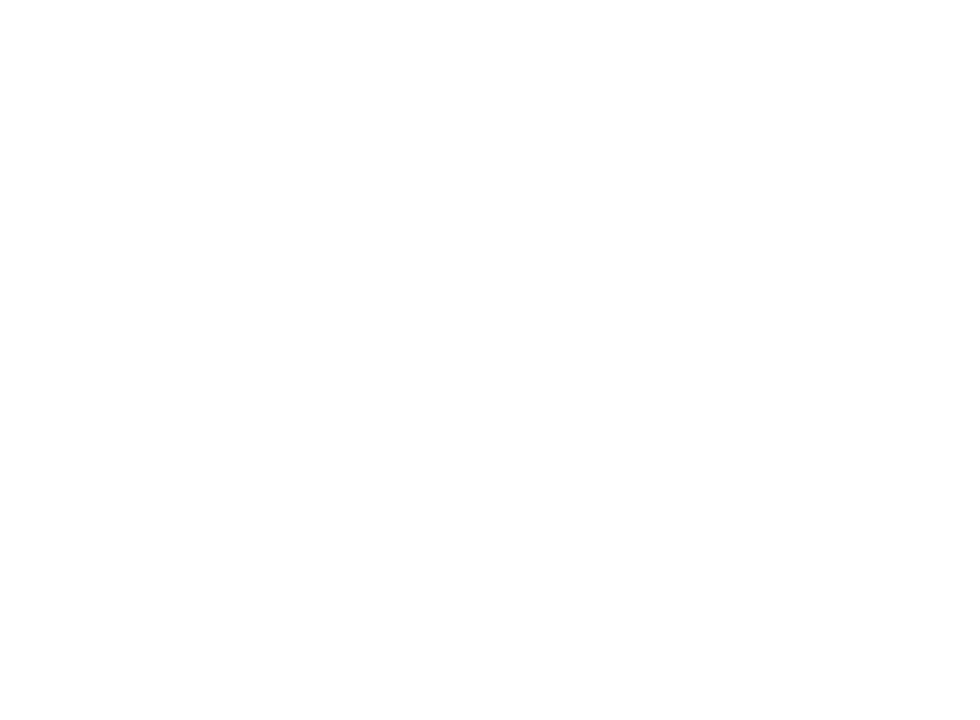

In [51]:
from IPython.display import SVG, display

_svg = r"""<svg viewBox="0 0 980 720" width="100%" style="max-width:980px;height:auto;display:block;margin:auto" xmlns="http://www.w3.org/2000/svg" role="img" aria-label="ActionExpert forward pass as a residual stream: each arrow is labelled with the equation from forward()">
<rect x="0" y="0" width="980" height="720" rx="16" fill="#FBFAF6"/>
<defs><marker id="up" viewBox="0 0 8 8" refX="4" refY="1.5" markerWidth="7.5" markerHeight="7.5" orient="auto"><path d="M0,7 L4,0 L8,7 z" fill="#5b564c"/></marker><marker id="rt" viewBox="0 0 8 8" refX="6.5" refY="4" markerWidth="7" markerHeight="7" orient="auto"><path d="M0,0 L7,4 L0,8 z" fill="#5b564c"/></marker></defs>
<path d="M500,665 V96" fill="none" stroke="#5b564c" stroke-width="2.2" marker-end="url(#up)"/>
<text x="510" y="150" font-size="11" fill="#5b564c" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">residual stream  x</text>
<path d="M500,262 C 430,262 446,254 436,244" fill="none" stroke="#b8b1a3" stroke-width="1.2"/>
<rect x="96" y="207.0" width="340" height="50" rx="8" fill="#C6DCEF" stroke="#7AA6C9" stroke-width="1.3"/>
<text x="110" y="227.0" font-size="10.5" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln2[1] = nn.LayerNorm(d)</text>
<text x="110" y="245.0" font-size="11.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">ff[1] = FeedForward(d)</text>
<path d="M436,232 H487" fill="none" stroke="#5b564c" stroke-width="1.6" marker-end="url(#rt)"/>
<circle cx="500" cy="232" r="11" fill="#FBFAF6" stroke="#5b564c" stroke-width="1.6"/>
<text x="500" y="236" text-anchor="middle" font-size="14" fill="#5b564c" font-family="system-ui,Segoe UI,sans-serif">+</text>
<text x="522" y="230" font-size="12" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = x + ff[1]( ln2[1](x) )</text>
<path d="M500,352 C 430,352 446,344 436,334" fill="none" stroke="#b8b1a3" stroke-width="1.2"/>
<rect x="96" y="297.0" width="340" height="50" rx="8" fill="#F8C98C" stroke="#CF9445" stroke-width="1.3"/>
<text x="110" y="317.0" font-size="10.5" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln1[1] = nn.LayerNorm(d)</text>
<text x="110" y="335.0" font-size="11.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">attn[1] = MHA(d, n_heads, causal=True)</text>
<path d="M436,322 H487" fill="none" stroke="#5b564c" stroke-width="1.6" marker-end="url(#rt)"/>
<circle cx="500" cy="322" r="11" fill="#FBFAF6" stroke="#5b564c" stroke-width="1.6"/>
<text x="500" y="326" text-anchor="middle" font-size="14" fill="#5b564c" font-family="system-ui,Segoe UI,sans-serif">+</text>
<text x="522" y="320" font-size="12" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = x + attn[1]( ln1[1](x) )</text>
<text x="522" y="335" font-size="10" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">SA · ctx = None (causal)</text>
<path d="M500,460 C 430,460 446,452 436,442" fill="none" stroke="#b8b1a3" stroke-width="1.2"/>
<rect x="96" y="405.0" width="340" height="50" rx="8" fill="#C6DCEF" stroke="#7AA6C9" stroke-width="1.3"/>
<text x="110" y="425.0" font-size="10.5" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln2[0] = nn.LayerNorm(d)</text>
<text x="110" y="443.0" font-size="11.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">ff[0] = FeedForward(d)</text>
<path d="M436,430 H487" fill="none" stroke="#5b564c" stroke-width="1.6" marker-end="url(#rt)"/>
<circle cx="500" cy="430" r="11" fill="#FBFAF6" stroke="#5b564c" stroke-width="1.6"/>
<text x="500" y="434" text-anchor="middle" font-size="14" fill="#5b564c" font-family="system-ui,Segoe UI,sans-serif">+</text>
<text x="522" y="428" font-size="12" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = x + ff[0]( ln2[0](x) )</text>
<path d="M500,550 C 430,550 446,542 436,532" fill="none" stroke="#b8b1a3" stroke-width="1.2"/>
<rect x="96" y="495.0" width="340" height="50" rx="8" fill="#F8C98C" stroke="#CF9445" stroke-width="1.3"/>
<text x="110" y="515.0" font-size="10.5" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln1[0] = nn.LayerNorm(d)</text>
<text x="110" y="533.0" font-size="11.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">attn[0] = MHA(d, n_heads, causal=False)</text>
<path d="M436,520 H487" fill="none" stroke="#5b564c" stroke-width="1.6" marker-end="url(#rt)"/>
<circle cx="500" cy="520" r="11" fill="#FBFAF6" stroke="#5b564c" stroke-width="1.6"/>
<text x="500" y="524" text-anchor="middle" font-size="14" fill="#5b564c" font-family="system-ui,Segoe UI,sans-serif">+</text>
<text x="522" y="518" font-size="12" fill="#B5502E" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = x + attn[0]( ln1[0](x), ctx=f )</text>
<text x="522" y="533" font-size="10" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">CA · ctx = f (reads feats)</text>
<rect x="150" y="152" width="700" height="30" rx="8" fill="#F3F1EC" stroke="#C9C3B6" stroke-width="1.2" stroke-dasharray="5 4"/>
<text x="500" y="171" text-anchor="middle" font-size="11" fill="#6b6456" font-family="system-ui,Segoe UI,sans-serif">… blocks 2 &amp; 3 repeat the same two equations (types → CA, then SA) …</text>
<rect x="340" y="74" width="320" height="44" rx="8" fill="#E7E3DA" stroke="#B4AEA1" stroke-width="1.3"/>
<text x="500" y="92" text-anchor="middle" font-size="11" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">ln_f = LayerNorm(d)   out = Linear(d, ACTION_DIM)</text>
<text x="500" y="108" text-anchor="middle" font-size="11.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">return self.out( self.ln_f(x) )</text>
<text x="500" y="42" text-anchor="middle" font-size="12.5" fill="#2E2B25" font-family="system-ui,Segoe UI,sans-serif">output — velocity  vθ   (B, n, ACTION_DIM)</text>
<path d="M500,74 V56" fill="none" stroke="#5b564c" stroke-width="2.2" marker-end="url(#up)"/>
<rect x="230" y="588" width="540" height="52" rx="8" fill="#E7E3DA" stroke="#B4AEA1" stroke-width="1.3"/>
<text x="500" y="609" text-anchor="middle" font-size="11.5" fill="#2E2B25" font-family="SFMono-Regular,Consolas,Menlo,monospace">x = in_proj(A^τ) + pos(arange n) + tau_embed(τ)</text>
<text x="500" y="627" text-anchor="middle" font-size="10" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">in_proj=Linear(ACTION_DIM,d)  pos=Embedding(CHUNK_LEN,d)  tau_embed=Linear(1,d)</text>
<text x="500" y="668" text-anchor="middle" font-size="11" fill="#6b6456" font-family="system-ui,Segoe UI,sans-serif">inputs:  A^τ (B,n,ACTION_DIM),  τ (B,1),  feats (B,S,FEAT_DIM)</text>
<text x="96" y="576" font-size="10.5" fill="#6b6456" font-family="SFMono-Regular,Consolas,Menlo,monospace">f = feat_proj(feats)   feat_proj = nn.Linear(FEAT_DIM, d)</text>
<path d="M150,570 V536" fill="none" stroke="#b8b1a3" stroke-width="1.2" stroke-dasharray="4 3" marker-end="url(#up)"/>
<text x="156" y="556" font-size="9.5" fill="#6b6456" font-style="italic" font-family="system-ui,Segoe UI,sans-serif">→ K/V for CA</text>
</svg>"""
display(SVG(_svg))

Every arrow maps to one statement in `forward`:

| arrow / node | equation in `forward` |
|---|---|
| input box | `x = in_proj(a_tau) + pos(arange n) + tau_embed(tau)` |
| feats side arrow | `f = feat_proj(feats)` |
| CA `+` (blocks 0, 2) | `x = x + attn[i](ln1[i](x), ctx=f)` |
| SA `+` (blocks 1, 3) | `x = x + attn[i](ln1[i](x))`  *(ctx = None, causal)* |
| FFN `+` (every block) | `x = x + ff[i](ln2[i](x))` |
| output box | `return out(ln_f(x))` |

So: **each box = the module**, **each arrow = the equation** that updates `x`.

## 5. Train with the flow-matching objective

The training step is a direct transcription of §2, and mirrors SmolVLA's loss
$\mathcal{L}(\theta)=\mathbb{E}\big[\lVert \mathbf{v}_\theta(\mathbf{A}^\tau, \mathbf{o}) - (\mathbf{A}-\boldsymbol{\varepsilon})\rVert^2\big]$:

1. sample a real chunk $\mathbf{A}$ and its features $\mathbf{o}$,
2. sample noise $\boldsymbol{\varepsilon}$ and a random time $\tau\in[0,1]$,
3. form the point on the line $\mathbf{A}^\tau=(1-\tau)\boldsymbol{\varepsilon}+\tau\mathbf{A}$,
4. regress the network's output onto the true velocity $\mathbf{A}-\boldsymbol{\varepsilon}$.

No `generate()`, no sampling loop during training — just one MSE per step.

In [52]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
for it in range(3001):
    goal, feats, A = make_batch(256)
    eps = torch.randn_like(A)                                  # noise at tau=0
    tau = torch.rand(A.size(0), 1, device=device)             # random time in [0,1]
    a_tau  = (1 - tau[..., None]) * eps + tau[..., None] * A   # point on the noise->data line
    target = A - eps                                           # the velocity that line travels at
    pred   = model(a_tau, tau, feats)                          # v_theta(A^tau, tau, o)
    loss   = F.mse_loss(pred, target)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if it % 500 == 0:
        print(f"step {it:4d} | flow-matching loss {loss.item():.4f}")

step    0 | flow-matching loss 1.8013
step  500 | flow-matching loss 0.0478
step 1000 | flow-matching loss 0.0258
step 1500 | flow-matching loss 0.0198
step 2000 | flow-matching loss 0.0281
step 2500 | flow-matching loss 0.0380
step 3000 | flow-matching loss 0.0196


## 6. Sample — integrate the ODE from noise to an action chunk

Inference is the flow-matching analogue of GPT's `generate()`. Start from pure noise and take a few
Euler steps along the learned velocity field:

$$\mathbf{x} \leftarrow \mathbf{x} + \mathbf{v}_\theta(\mathbf{x}, \tau, \mathbf{o})\,\Delta\tau, \qquad \tau: 0 \to 1.$$

With ~20 steps the endpoint of the sampled chunk should land on the goal encoded in the VLM features —
i.e. the expert has learned to *read the observation via cross-attention* and *emit a valid trajectory
via flow matching*.

In [53]:
@torch.no_grad()
def sample_chunk(feats, steps=20):
    """Generate an action chunk by integrating the velocity field from noise (tau=0) to data (tau=1)."""
    B = feats.size(0)
    x = torch.randn(B, CHUNK_LEN, ACTION_DIM, device=device)   # start at pure noise
    for i in range(steps):
        tau = torch.full((B, 1), i / steps, device=device)
        x = x + model(x, tau, feats) * (1.0 / steps)           # Euler step along v_theta
    return x

goal, feats, A = make_batch(512)
pred = sample_chunk(feats)
endpoint_err = (pred[:, -1, :] - goal).norm(dim=-1).mean().item()
print(f"mean endpoint error (sampled final action vs goal): {endpoint_err:.3f}")
for b in range(3):
    print(f"  goal {[round(v,2) for v in goal[b].tolist()]}  ->  "
          f"sampled endpoint {[round(v,2) for v in pred[b, -1].tolist()]}")

mean endpoint error (sampled final action vs goal): 0.029
  goal [1.24, 1.46]  ->  sampled endpoint [1.26, 1.49]
  goal [-1.96, -1.06]  ->  sampled endpoint [-2.0, -1.11]
  goal [-1.53, -0.46]  ->  sampled endpoint [-1.56, -0.48]


### Optional: see the trajectories
If `matplotlib` is installed, this plots a few sampled action chunks (lines) against their goals
(stars). They should trace roughly straight paths from the origin to each goal.

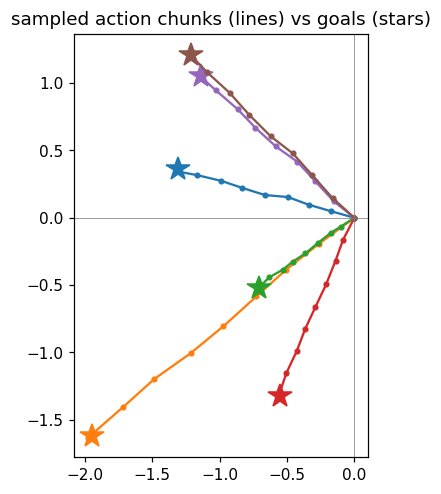

In [54]:
# Optional: plot a few sampled trajectories vs their goals.
# We force the non-interactive "Agg" backend and display a PNG, which avoids Jupyter's
# inline backend — that path crashes on some matplotlib/matplotlib-inline version mismatches
# (e.g. AttributeError: 'RcParams' object has no attribute '_get').
try:
    import matplotlib
    matplotlib.use("Agg")                     # must be set before importing pyplot
    import matplotlib.pyplot as plt
    import numpy as np, io
    from IPython.display import Image, display
except Exception as e:
    print("matplotlib unavailable - skipping the plot:", repr(e))
else:
    if ACTION_DIM != 2:
        print(f"this plot assumes 2-D actions; ACTION_DIM={ACTION_DIM}, so skipping.")
    else:
        g, f, _ = make_batch(6)
        traj  = sample_chunk(f).cpu().numpy()          # (6, CHUNK_LEN, 2)
        goals = g.cpu().numpy()                         # (6, 2)
        fig, ax = plt.subplots(figsize=(5, 5))
        for b in range(6):
            xy = np.vstack([[0.0, 0.0], traj[b]])       # prepend the origin -> (n+1, 2)
            ln, = ax.plot(xy[:, 0], xy[:, 1], "-o", ms=3)
            ax.plot(goals[b, 0], goals[b, 1], "*", ms=16, color=ln.get_color())
        ax.set_title("sampled action chunks (lines) vs goals (stars)")
        ax.axhline(0, lw=.5, c="gray"); ax.axvline(0, lw=.5, c="gray"); ax.set_aspect("equal")
        buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
        display(Image(data=buf.getvalue()))


## 7. From this toy to real SmolVLA — and to this repo

You just built the mechanism at the heart of SmolVLA's action expert. Here is what the real system
adds on top, and where each piece lives in `SmolVLA.pdf`:

- **Real VLM features (§3.1).** Our fixed random `make_batch` stands in for **SmolVLM-2**: a SigLIP
  vision encoder + SmolLM2 decoder. Images are pixel-shuffled to **64 visual tokens**, the language
  instruction is tokenized, and the robot **state** is projected to a **single token** by a linear
  layer; all are concatenated and run through the decoder. The action expert cross-attends to the
  resulting features — exactly our `feats`.
- **Layer skipping (§3.1).** SmolVLA conditions on features from layer **N = L/2**, not the last layer,
  halving both the VLM and the expert's compute. A speed knob, not a new mechanism.
- **Skinny expert (§3.1).** The expert uses hidden size **0.75×d** of the VLM, for cheaper inference.
- **Beta-sampled time.** SmolVLA samples `τ` from a **Beta** distribution (not uniform) to focus
  training near the data end of the path. Try swapping `torch.rand` for a Beta sample below.
- **Asynchronous inference (§3.3).** Because the expert emits a *chunk*, a `RobotClient` executes from a
  queue while a (possibly remote) `PolicyServer` computes the next chunk — the key to running on
  low-power edge hardware. That is precisely what this repo (`openspec/changes/smolvla-edge-deployment/`)
  is about: fine-tuning, on-device inference, the client/server split, and latency benchmarking.

### Exercises
1. **Multimodality.** Make each goal reachable by *two* trajectories (e.g. clockwise vs counter-clockwise
   arc) and confirm flow-matching samples pick one mode per run, instead of averaging to the middle.
2. **Beta time.** Replace `tau = torch.rand(...)` with a `Beta(1.5, 1.0)` sample and see if fewer Euler
   steps then suffice at sampling time.
3. **Ablate cross-attention.** Set `layer_types=("sa","sa","sa","sa")` (no CA). The expert can no longer
   read the goal — watch the endpoint error blow up. This isolates *what cross-attention buys you*.
4. **Chunk causality.** Print an SA layer's attention weights and confirm they are lower-triangular over
   the chunk (no action attends to a future action), just like Part 1.
5. **Fewer Euler steps.** Drop `steps` in `sample_chunk` from 20 → 5 → 2 and watch endpoint error vs
   inference cost — the trade-off that matters on the edge.


## 8 — Bonus: a minimal closed-loop rollout (dynamics + re-observation)

**Scope recap.** Everything above predicts **one** action chunk, **open-loop**, against a **fixed
target** — there are **no dynamics** (`A = goal * t` is a hand-built trajectory, not a simulated
system) and **no feedback**. That deliberately isolates the *policy* (the flow-matching action expert).

Here we wrap the **same trained model** in the receding-horizon loop a real robot uses — a toy version
of SmolVLA's asynchronous chunk consumption (&sect;3.3):

1. **Re-observe** — build features from the goal *relative to the current position* (the feedback signal).
2. **Predict** a chunk of displacement waypoints with the trained expert.
3. **Execute** the first few via toy **dynamics** — a 2-D point that *servos* a fraction toward each
   commanded target (so it moves through the world instead of teleporting).
4. **Repeat** from the new position until the goal is reached.

Because each re-observation feeds the model the *remaining* vector to the goal, the loop **converges**.
This is a minimal illustration of the predict &rarr; execute &rarr; re-observe cycle the open-loop toy
omits — not a separately-trained closed-loop policy.

> **Sync, not async.** This toy is **synchronous**: the robot sits idle while the expert plans, then
> executes `steps_per_chunk` waypoints, then re-plans. SmolVLA's *asynchronous* inference (&sect;3.3)
> instead keeps executing the current chunk *while the next is computed in parallel*, then aggregates the
> overlap. `steps_per_chunk` sets how many of the `CHUNK_LEN` predicted waypoints are executed before
> re-planning — the rest are **discarded** (receding horizon).


start [0.0, 0.0]  ->  goal [1.5, -1.0]  ->  final [1.478, -0.951]
closed-loop control steps: 36 | final distance to goal: 0.0538


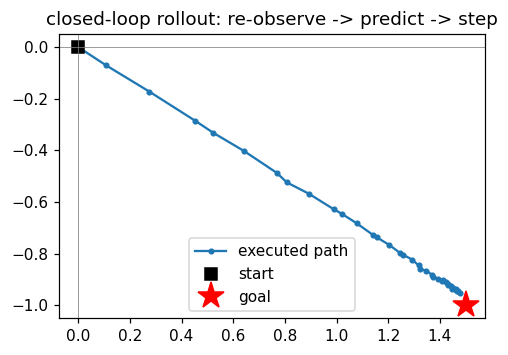

In [55]:
# Closed-loop rollout: predict -> step toy dynamics -> re-observe -> predict (needs the TRAINED model).
@torch.no_grad()
def observe(goal, pos):
    rel = goal - pos                                    # what still remains to do (the feedback signal)
    h = torch.tanh(rel @ Wg)
    return (h @ Wf).view(1, FEAT_TOKENS, FEAT_DIM)      # fake VLM features of the re-observation

def rollout(goal, steps_per_chunk=3, servo=0.6, max_replans=12, tol=0.05):
    pos = torch.zeros(1, ACTION_DIM, device=device)     # start at the origin
    path = [pos.clone()]
    for _ in range(max_replans):
        feats  = observe(goal, pos)                     # RE-OBSERVE
        chunk  = sample_chunk(feats)[0]                 # PREDICT a chunk (displacement waypoints)
        target = pos + chunk                            # interpret as absolute targets from here
        # EXECUTE only the first steps_per_chunk of the CHUNK_LEN predicted waypoints; discard the
        # rest and re-plan (receding horizon). SYNCHRONOUS: plan, then execute, then re-plan.
        for k in range(min(steps_per_chunk, target.shape[0])):
            pos = pos + servo * (target[k:k+1] - pos)   # STEP toy dynamics (servo toward the target)
            path.append(pos.clone())
        if (goal - pos).norm() < tol:                   # reached -> stop replanning
            break
    return torch.cat(path, 0)

goal = torch.tensor([[1.5, -1.0]], device=device)
path = rollout(goal).cpu().numpy()
final_dist = ((goal.cpu().numpy()[0] - path[-1]) ** 2).sum() ** 0.5
print(f"start [0.0, 0.0]  ->  goal {goal[0].tolist()}  ->  final {[round(v,3) for v in path[-1].tolist()]}")
print(f"closed-loop control steps: {len(path) - 1} | final distance to goal: {final_dist:.4f}")

# optional plot of the executed path (robust Agg backend, as in the earlier cell)
try:
    import matplotlib; matplotlib.use("Agg")
    import matplotlib.pyplot as plt, io
    from IPython.display import Image, display
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(path[:, 0], path[:, 1], "-o", ms=3, label="executed path")
    ax.plot(0, 0, "ks", ms=8, label="start")
    ax.plot(goal.cpu().numpy()[0, 0], goal.cpu().numpy()[0, 1], "r*", ms=18, label="goal")
    ax.set_title("closed-loop rollout: re-observe -> predict -> step")
    ax.axhline(0, lw=.5, c="gray"); ax.axvline(0, lw=.5, c="gray")
    ax.set_aspect("equal"); ax.legend()
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    display(Image(data=buf.getvalue()))
except Exception as e:
    print("plot skipped:", repr(e))


### Animation — the planned action chunk vs the executed path

Like a planned-trajectory overlay in autonomous driving: at every control step the **orange** dashed
line is the *full chunk the action expert just predicted* (`CHUNK_LEN` waypoints from the current
position), and the **blue** line is what the robot has actually executed. Watch the plan **re-snap**
each time the loop re-observes and predicts a fresh chunk. (Run **after training**; needs `pillow`.)

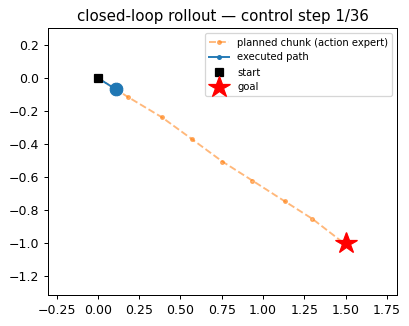

36 control steps | final distance to goal: 0.057


In [56]:
# AV-style animation: planned chunk (orange) overlaid on the executed path (blue), as an in-memory GIF.
# Frames are rendered with the Agg backend and assembled by Pillow -> avoids Jupyter's inline backend.
try:
    import matplotlib; matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np, io
    from PIL import Image as PILImage
    from IPython.display import Image, display
except Exception as e:
    print("animation needs matplotlib + pillow - skipping:", repr(e))
else:
    def rollout_frames(goal, steps_per_chunk=3, servo=0.6, max_replans=12, tol=0.05):
        pos = torch.zeros(1, ACTION_DIM, device=device)
        executed = [pos.cpu().numpy()[0].copy()]
        frames = []
        for _ in range(max_replans):
            chunk  = sample_chunk(observe(goal, pos))[0]                  # PREDICT full chunk
            target = pos + chunk
            plan   = np.vstack([pos.cpu().numpy(), target.cpu().numpy()]) # the plan to draw
            for k in range(min(steps_per_chunk, target.shape[0])):
                pos = pos + servo * (target[k:k+1] - pos)                 # STEP dynamics
                executed.append(pos.cpu().numpy()[0].copy())
                frames.append((np.array(executed), plan))
            if (goal - pos).norm() < tol:
                break
        return frames

    goal = torch.tensor([[1.5, -1.0]], device=device)
    frames = rollout_frames(goal)
    gxy = goal.cpu().numpy()[0]
    pts = np.vstack([f[0] for f in frames] + [f[1] for f in frames] + [[0.0, 0.0], gxy])
    lo, hi = pts.min(0) - 0.3, pts.max(0) + 0.3

    imgs = []
    for i, (ep, pl) in enumerate(frames):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(pl[:, 0], pl[:, 1], "--o", color="tab:orange", alpha=.55, ms=3, label="planned chunk (action expert)")
        ax.plot(ep[:, 0], ep[:, 1], "-o", color="tab:blue", ms=3, label="executed path")
        ax.plot(ep[-1, 0], ep[-1, 1], "o", color="tab:blue", ms=10)          # the "robot"
        ax.plot(0, 0, "ks", ms=7, label="start"); ax.plot(gxy[0], gxy[1], "r*", ms=18, label="goal")
        ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_aspect("equal")
        ax.legend(loc="best", fontsize=8); ax.set_title(f"closed-loop rollout — control step {i+1}/{len(frames)}")
        buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=90, bbox_inches="tight"); plt.close(fig)
        buf.seek(0); imgs.append(PILImage.open(buf).convert("RGB"))

    gif = io.BytesIO()
    imgs[0].save(gif, format="GIF", save_all=True, append_images=imgs[1:], duration=320, loop=0)
    display(Image(data=gif.getvalue()))
    print(f"{len(frames)} control steps | final distance to goal: {np.linalg.norm(gxy - frames[-1][0][-1]):.3f}")
